# Inspect Low-Quality US-PD-Newspapers (1950-1999)

The `predicted_quality` column is a Ridge regression score (trained in
`src/base_training/quality/train_ridge_models.py`) on BGE embeddings with
human labels on a 1-5 scale.

This notebook:
1. Loads the metadata index for 1950-1999
2. Filters to `US-PD-Newspapers`
3. Shows the quality score distribution
4. Retrieves and displays actual text for the lowest-scoring documents

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, HTML
import sys

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.post_training.config import get_paths

In [2]:
period = "1950_1999"
collection_name = "US-PD-Newspapers"

paths = get_paths(period)
meta = pd.read_parquet(paths["metadata_index"])

news = meta[meta["collection"] == collection_name].copy()
print(f"Total docs in index: {len(meta):,}")
print(f"{collection_name} docs: {len(news):,}")

Total docs in index: 5,993,969
US-PD-Newspapers docs: 386,076


## 1. Quality score distribution

In [3]:
q = news["predicted_quality"]

print(f"Quality score stats for {collection_name}:")
print(f"  Count:  {len(q):,}")
print(f"  Mean:   {q.mean():.4f}")
print(f"  Median: {q.median():.4f}")
print(f"  Std:    {q.std():.4f}")
print(f"  Min:    {q.min():.4f}")
print(f"  Max:    {q.max():.4f}")
print()

print("Percentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {q.quantile(p/100):.4f}")

# Quality filter threshold used in export.py (quality_percentile=50)
global_threshold = meta["predicted_quality"].quantile(0.50)
n_pass = (q >= global_threshold).sum()
print(f"\nGlobal p50 threshold: {global_threshold:.4f}")
print(f"{collection_name} docs passing global p50: {n_pass:,} / {len(q):,} ({n_pass/len(q)*100:.1f}%)")

Quality score stats for US-PD-Newspapers:
  Count:  386,076
  Mean:   2.5809
  Median: 2.6013
  Std:    0.4980
  Min:    0.0263
  Max:    4.5469

Percentiles:
  p 1: 1.3618
  p 5: 1.7373
  p10: 1.9293
  p25: 2.2491
  p50: 2.6013
  p75: 2.9262
  p90: 3.2045
  p95: 3.3673
  p99: 3.6641

Global p50 threshold: 3.9002
US-PD-Newspapers docs passing global p50: 804 / 386,076 (0.2%)


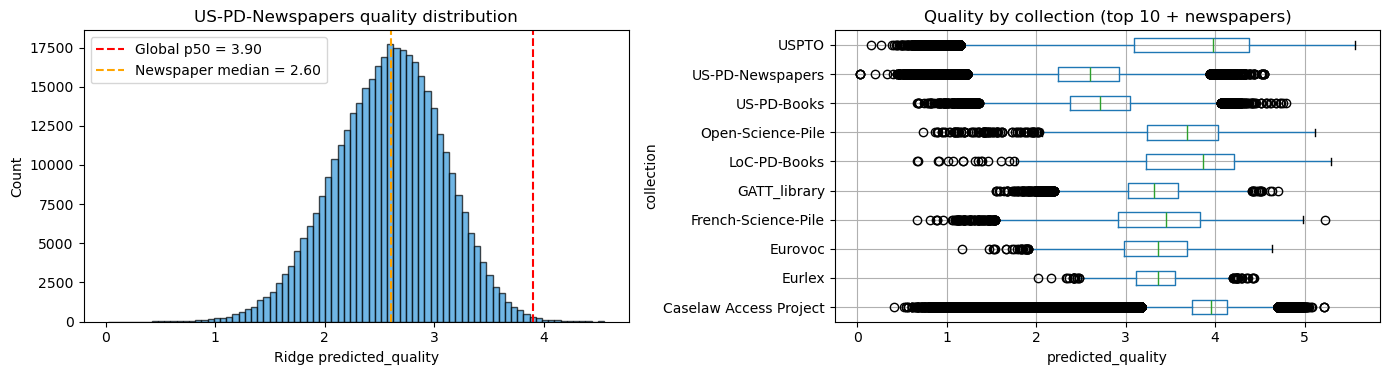

In [4]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histogram
    axes[0].hist(q, bins=80, color="#3498db", edgecolor="black", alpha=0.7)
    axes[0].axvline(global_threshold, color="red", ls="--", lw=1.5,
                    label=f"Global p50 = {global_threshold:.2f}")
    axes[0].axvline(q.median(), color="orange", ls="--", lw=1.5,
                    label=f"Newspaper median = {q.median():.2f}")
    axes[0].set_xlabel("Ridge predicted_quality")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{collection_name} quality distribution")
    axes[0].legend()

    # Compare with all collections (box plot)
    top_collections = meta["collection"].value_counts().head(10).index.tolist()
    if collection_name not in top_collections:
        top_collections.append(collection_name)
    subset = meta[meta["collection"].isin(top_collections)]
    subset.boxplot(column="predicted_quality", by="collection", ax=axes[1],
                   vert=False, figsize=(14, 4))
    axes[1].set_title("Quality by collection (top 10 + newspapers)")
    axes[1].set_xlabel("predicted_quality")
    fig.suptitle("")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available - skipping plots")

## 2. Retrieve text for low-quality samples

Pull actual document text from `D:/English/{year}/subset_*.parquet` for the
lowest-scoring newspaper articles.

In [5]:
N_SAMPLES = 20  # how many low-quality docs to inspect

low_q = news.nsmallest(N_SAMPLES, "predicted_quality")
print(f"Fetching text for the {N_SAMPLES} lowest-scoring {collection_name} docs")
print(f"Score range: {low_q['predicted_quality'].min():.4f} - {low_q['predicted_quality'].max():.4f}\n")

raw_root = paths["raw_data_root"]  # D:/English

texts = {}
for (year, subset_file), group in low_q.groupby(["year", "subset_file"]):
    parquet_path = raw_root / str(year) / subset_file
    if not parquet_path.exists():
        print(f"  WARNING: {parquet_path} not found")
        continue
    needed = set(group["identifier"])
    raw = pd.read_parquet(parquet_path, columns=["identifier", "text"])
    matched = raw[raw["identifier"].isin(needed)]
    for _, row in matched.iterrows():
        texts[row["identifier"]] = row["text"] if pd.notna(row["text"]) else "[empty]"

low_q = low_q.copy()
low_q["text"] = low_q["identifier"].map(texts)
print(f"Retrieved {low_q['text'].notna().sum()} / {N_SAMPLES} documents")

Fetching text for the 20 lowest-scoring US-PD-Newspapers docs
Score range: 0.0263 - 0.4769

Retrieved 20 / 20 documents


In [6]:
# Display low-quality samples
PREVIEW_CHARS = 3000  # max characters to show per document

for i, (_, row) in enumerate(low_q.iterrows(), 1):
    text = row.get("text", "[not retrieved]")
    if pd.isna(text):
        text = "[not retrieved]"
    preview = text[:PREVIEW_CHARS] + ("..." if len(str(text)) > PREVIEW_CHARS else "")

    print(f"{'='*80}")
    print(f"[{i}/{N_SAMPLES}]  Score: {row['predicted_quality']:.4f}  |  "
          f"Year: {row['year']}  |  ID: {row['identifier']}")
    print(f"{'='*80}")
    print(preview)
    print()

[1/20]  Score: 0.0263  |  Year: 1954  |  ID: sn83045462_1954-10-03_1_174_1
PAY-AND- NIGHT you SAY HE'S UP TO CALL THE VILLAGE POLICE AND CAY. TAKE JANIE INTO THE AUTO SERVICE - YOUR SHOP. HEAPING, TELL THEM TO SEND A CAR TO THIS BEDROOM AND LOCK YOURSELF. 

[2/20]  Score: 0.0263  |  Year: 1954  |  ID: sn83045462_1954-10-03_1_174_1
PAY-AND- NIGHT you SAY HE'S UP TO CALL THE VILLAGE POLICE AND CAY. TAKE JANIE INTO THE AUTO SERVICE - YOUR SHOP. HEAPING, TELL THEM TO SEND A CAR TO THIS BEDROOM AND LOCK YOURSELF. 

[3/20]  Score: 0.0263  |  Year: 1954  |  ID: sn83045462_1954-10-03_1_174_1
PAY-AND- NIGHT you SAY HE'S UP TO CALL THE VILLAGE POLICE AND CAY. TAKE JANIE INTO THE AUTO SERVICE - YOUR SHOP. HEAPING, TELL THEM TO SEND A CAR TO THIS BEDROOM AND LOCK YOURSELF. 

[4/20]  Score: 0.0263  |  Year: 1954  |  ID: sn83045462_1954-10-03_1_174_1
PAY-AND- NIGHT you SAY HE'S UP TO CALL THE VILLAGE POLICE AND CAY. TAKE JANIE INTO THE AUTO SERVICE - YOUR SHOP. HEAPING, TELL THEM TO SEND A CAR TO TH

## 3. Compare: what do high-quality newspaper articles look like?

In [ ]:
N_HIGH = 5  # high-quality samples for comparison

high_q = news.nlargest(N_HIGH, "predicted_quality")

texts_high = {}
for (year, subset_file), group in high_q.groupby(["year", "subset_file"]):
    parquet_path = raw_root / str(year) / subset_file
    if not parquet_path.exists():
        continue
    needed = set(group["identifier"])
    raw = pd.read_parquet(parquet_path, columns=["identifier", "text"])
    matched = raw[raw["identifier"].isin(needed)]
    for _, row in matched.iterrows():
        texts_high[row["identifier"]] = row["text"] if pd.notna(row["text"]) else "[empty]"

high_q = high_q.copy()
high_q["text"] = high_q["identifier"].map(texts_high)

print(f"Top {N_HIGH} highest-scoring {collection_name} docs for comparison:\n")
for i, (_, row) in enumerate(high_q.iterrows(), 1):
    text = row.get("text", "[not retrieved]")
    if pd.isna(text):
        text = "[not retrieved]"
    preview = text[:PREVIEW_CHARS] + ("..." if len(str(text)) > PREVIEW_CHARS else "")

    print(f"{'='*80}")
    print(f"[{i}/{N_HIGH}]  Score: {row['predicted_quality']:.4f}  |  "
          f"Year: {row['year']}  |  ID: {row['identifier']}")
    print(f"{'='*80}")
    print(preview)
    print()

## 4. Samples around the quality filter cutoff

The export pipeline uses the global p50 threshold. Let's see what articles
are right at the boundary (just above and just below the cutoff).

In [ ]:
N_BOUNDARY = 5

# Docs just below the cutoff (would be filtered out)
below = news[news["predicted_quality"] < global_threshold].nlargest(N_BOUNDARY, "predicted_quality")
# Docs just above the cutoff (would be kept)
above = news[news["predicted_quality"] >= global_threshold].nsmallest(N_BOUNDARY, "predicted_quality")

boundary = pd.concat([below, above]).sort_values("predicted_quality")

texts_boundary = {}
for (year, subset_file), group in boundary.groupby(["year", "subset_file"]):
    parquet_path = raw_root / str(year) / subset_file
    if not parquet_path.exists():
        continue
    needed = set(group["identifier"])
    raw = pd.read_parquet(parquet_path, columns=["identifier", "text"])
    matched = raw[raw["identifier"].isin(needed)]
    for _, row in matched.iterrows():
        texts_boundary[row["identifier"]] = row["text"] if pd.notna(row["text"]) else "[empty]"

boundary = boundary.copy()
boundary["text"] = boundary["identifier"].map(texts_boundary)

print(f"Global p50 threshold: {global_threshold:.4f}")
print(f"Docs just BELOW (filtered out) and ABOVE (kept) the cutoff:\n")

for i, (_, row) in enumerate(boundary.iterrows(), 1):
    text = row.get("text", "[not retrieved]")
    if pd.isna(text):
        text = "[not retrieved]"
    preview = text[:2000] + ("..." if len(str(text)) > 2000 else "")
    status = "KEPT" if row["predicted_quality"] >= global_threshold else "FILTERED OUT"

    print(f"{'='*80}")
    print(f"[{status}]  Score: {row['predicted_quality']:.4f}  |  "
          f"Year: {row['year']}  |  ID: {row['identifier']}")
    print(f"{'='*80}")
    print(preview)
    print()